In [20]:
import importlib
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import deeptime
import scipy


import npc_msm
importlib.reload(npc_msm)
from npc_msm import run
# --
import raveh_2025.show_transport_stats_v3
importlib.reload(raveh_2025.show_transport_stats_v3)
from raveh_2025.show_transport_stats_v3 import read_df, calc_filtered_transport_stats
# --
import utils
importlib.reload(utils)
from utils import radius_a_to_kda, amount_to_concentration

In [23]:
for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        for subset in [0.035]:
    # for radius in [22]:
            print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
            checkpoint_path = f"data/ntr_variants/{sites}_{radius}_more/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 70000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants/{sites}_{10}_more/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.01
            params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            
            # bootstraps:
            # params['BOOTSTRAP_REPEATS'] = 100
            # params['N_CLUSTERS'] = [640]
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [80]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            
            run(checkpoint_path, params_override=params, start_stage=5, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
Running stage 5...
Reduced from 80 to 42 clusters after merging heavy nuc/cys centroids (nuc merged: 23, cys merged: 15)
Reduced from 42 to 42 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 3438.3966901026683 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 14 ~~~~~~~
Running stage 5...
Reduced from 80 to 42 clusters after merging heavy nuc/cys centroids (nuc merged: 23, cys merged: 15)
Reduced from 42 to 42 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1184.8573234874875 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 18 ~~~~~~~
Running stage 5...
Reduced from 80 to 42 clusters after merging heavy nuc/cys centroids (nuc merged: 23, cys merge

In [14]:
df = read_df("raveh_2025/all.csv")
slice = calc_filtered_transport_stats(df)
SCALING_FACTOR_FROM_PASSIVE_EXP = 200.0 # raveh 2025

x = slice['MW_kDa']
y = slice['transport_per_sec_per_particle_per_uM'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.01
y_low = slice['transport_per_sec_per_particle_per_uM_95low'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.005
y_high = slice['transport_per_sec_per_particle_per_uM_95high'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.01


/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/raveh_2025/show_transport_stats_v3.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.at[index,'transport_5us_per_sec_per_particle']= (row_transport * dT - big_sister_transport * (dT-5e-6)) / 5e-6


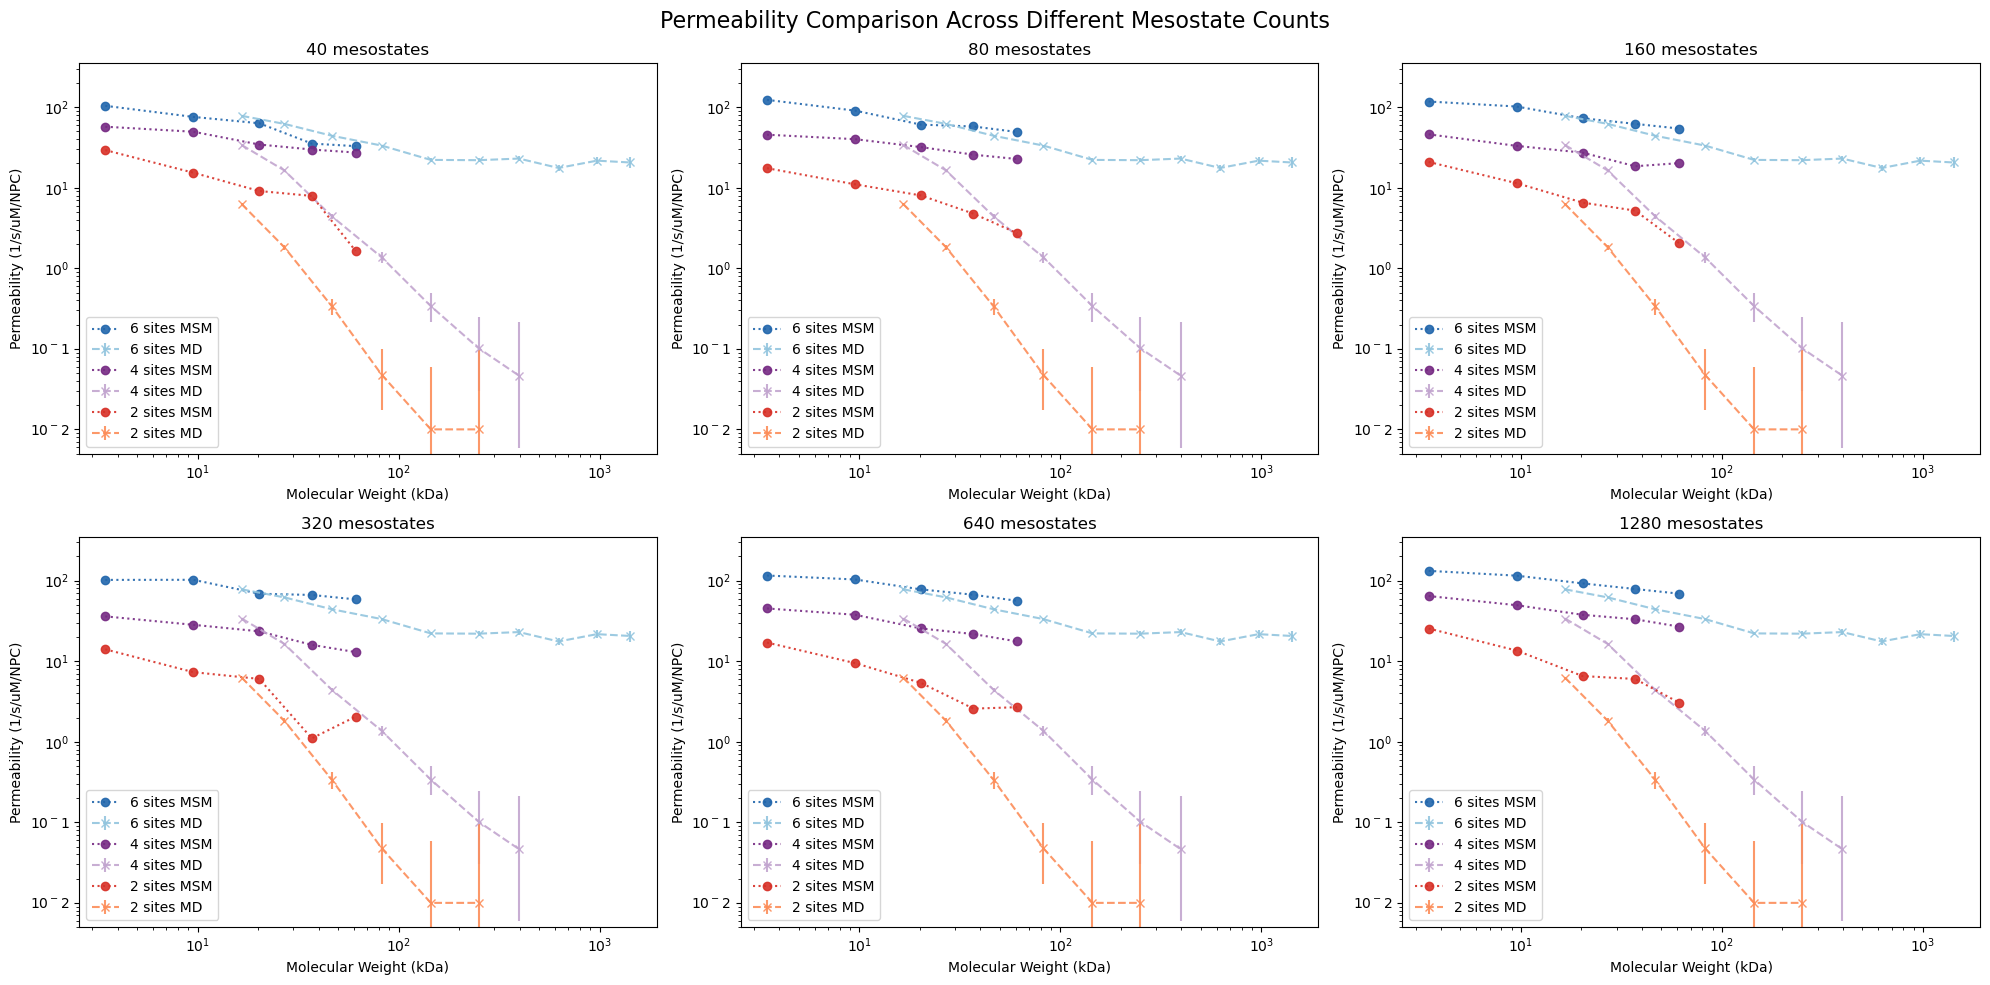

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()  # Make it easier to iterate
n_sites = [2, 4, 6]
radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii] 
for i, n_clusters in enumerate([40, 80, 160, 320, 640, 1280]):
    permeabilities_means = {2: [], 4: [], 6: []}
    permeabilities_stds = {}
    for sites in [2, 4, 6]:
        for radius in [10, 14, 18, 22, 26]:
            with open(f"data/ntr_variants/{sites}_{radius}/7_permeabilities.pickle", "rb") as f:
                permeabilities_means[sites].append(pickle.load(f)[n_clusters])
            # with open(f"data/ntr_variants/{sites}_sites/bmsm_permeabilities/std-{n_clusters}clusters.pickle", "rb") as f:
            #     permeabilities_stds[sites] = pickle.load(f)
            
    ax = axes[i]
    
    msm_colors = ["#2166ac", "#762a83", "#d73027"]
    md_colors = ["#92c5de", "#c2a5cf", "#fc8d59"]
    for i, sites in enumerate([6, 4, 2]):
        ax.errorbar(kdas, np.array(permeabilities_means[sites]) / (SCALING_FACTOR_FROM_PASSIVE_EXP - 100),
                    # yerr= 1.96 * np.array(permeabilities_stds[sites]) / SCALING_FACTOR_FROM_PASSIVE_EXP,
                    marker='o',
                label=f'{sites} sites MSM', color=msm_colors[i], alpha=0.9, linestyle=':')
        mask = slice['n_sites'] == sites
        ax.errorbar(x[mask], y[mask], 
                    yerr=[y[mask] - y_low[mask], y_high[mask] - y[mask]],
                    fmt='x--', color=md_colors[i], label=f'{sites} sites MD', alpha=0.9)


    
    # x axis
    ax.set_xlabel('Molecular Weight (kDa)')
    # ax.set_xlim(kdas[0], kdas[-1]) 
    ax.set_xscale('log')
    ax.set_xticks([10**1, 10**2, 10**3])
    ax.set_xticklabels([r'$10^1$', r'$10^2$', r'$10^3$'])
    
    # y axis
    ax.set_ylabel('Permeability (1/s/uM/NPC)')
    ax.set_yscale('log')
    ax.set_yticks([10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3])
    ax.set_yticklabels([r'$10^-2$' ,r'$10^-1$', r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$'])
    ax.set_ylim([0.005, 350])

    ax.set_title(f"{n_clusters} mesostates")
    ax.legend()


plt.suptitle("Permeability Comparison Across Different Mesostate Counts", fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
# Visualize empirical permeabilities
import pandas as pd
import matplotlib.pyplot as plt

n_sites = [2, 4, 6]
radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]

def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md(time_us=20, n_trajs=3000, n_clusters=640):
    results = []
    for sites in n_sites:
        for radius in radii:
            clustered_path = f"data/ntr_variants/{sites}_{radius}/5_clustered/{n_clusters}clusters.pickle"
            clustering_path = f"data/ntr_variants/{sites}_{radius}/5_clustering/{n_clusters}clusters.pickle"
            
            n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(time_us, n_trajs, clustered_path, clustering_path)
            
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'total_transports': total_full_transports,
                'n_trajs': n_trajs,
                'permeability': permeability,
                'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                'upper_permeability': upper_permeability if upper_permeability >=0 else 0
            })
    return results

def collect_perms_md_single_type(time_us, n_trajs, clustered_path, clustering_path):
    total_full_transports = 0
    with open(clustered_path, "rb") as f:
        clustered = pickle.load(f)
    clustered = clustered[:n_trajs] # should be len(clustered)//8 == 3000
                
    with open(clustering_path, "rb") as f:
        clustering = pickle.load(f)
    from _016_EXP_clustered_master_figure import estimate_cluters_mu_cov, calc_coordinate_edges_dict
    from utils import get_sorted_anchor_coordinates_np
    anchor_coordinates = get_sorted_anchor_coordinates_np()[1]
    coordinate_edges = calc_coordinate_edges_dict(anchor_coordinates)
    mus, covs = estimate_cluters_mu_cov(2000, clustering.centroids, coordinate_edges, range(clustering.centroids.shape[0]))
    bottom_indices = np.where(mus[:, 1] <= -10)[0]
    top_indices = np.where(mus[:, 1] >= 10)[0]

    n_trajs = clustered.shape[0]
    for i in range(n_trajs):
        traj = clustered[i]
        last_side = None
        
        for element in traj:
            if element in bottom_indices:
                current_side = 0
            elif element in top_indices:
                current_side = 1
            else:
                continue  # Skip neutral/middle regions
            
            if last_side is None:
                last_side = current_side  # Initialize, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6
    n_sims = 30

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs,total_full_transports,permeability,lower_permeability,upper_permeability

def collect_perms_msm_bootstrap(n_clusters=640):
    results = []
    for sites in n_sites:
        for radius in radii:
            with open(f"data/ntr_variants/{sites}_{radius}/7_permeabilities_bootstrap.pickle", "rb") as f:
                bootstrapped_perms = pickle.load(f)
            n_bootstraps = len(bootstrapped_perms)
            perms = []
            for b in range(n_bootstraps):
                perms.append(bootstrapped_perms[b][n_clusters])
            perms = np.array(perms)
            meadian_perm = np.median(perms)
            lower = np.percentile(perms, 5)
            upper = np.percentile(perms, 95)
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'median_permeability': meadian_perm,
                'lower_permeability': lower,
                'upper_permeability': upper
            })
    return results

def weighted_power_law_fit(x, y, y_err=None):
    weights = None
    if y_err is not None:
        log_y_err = y_err / y
        weights = 1 / (log_y_err ** 2)
        weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)
        weights = weights / np.mean(weights)
        weights = np.clip(weights, 0.1, 10)

    coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = 10 ** poly(np.log10(x_fit))
    y_fit_per_original_x = 10 ** poly(np.log10(x))
    slope, intercept = coeffs
    return x_fit, y_fit, slope, intercept, y_fit_per_original_x

In [ ]:
results_emp = collect_perms_md(time_us=20, n_trajs=3000, n_clusters=640)
df_results_emp = pd.DataFrame(results_emp)
results_tm = collect_perms_msm_bootstrap(n_clusters=640)
df_results_tm = pd.DataFrame(results_tm)

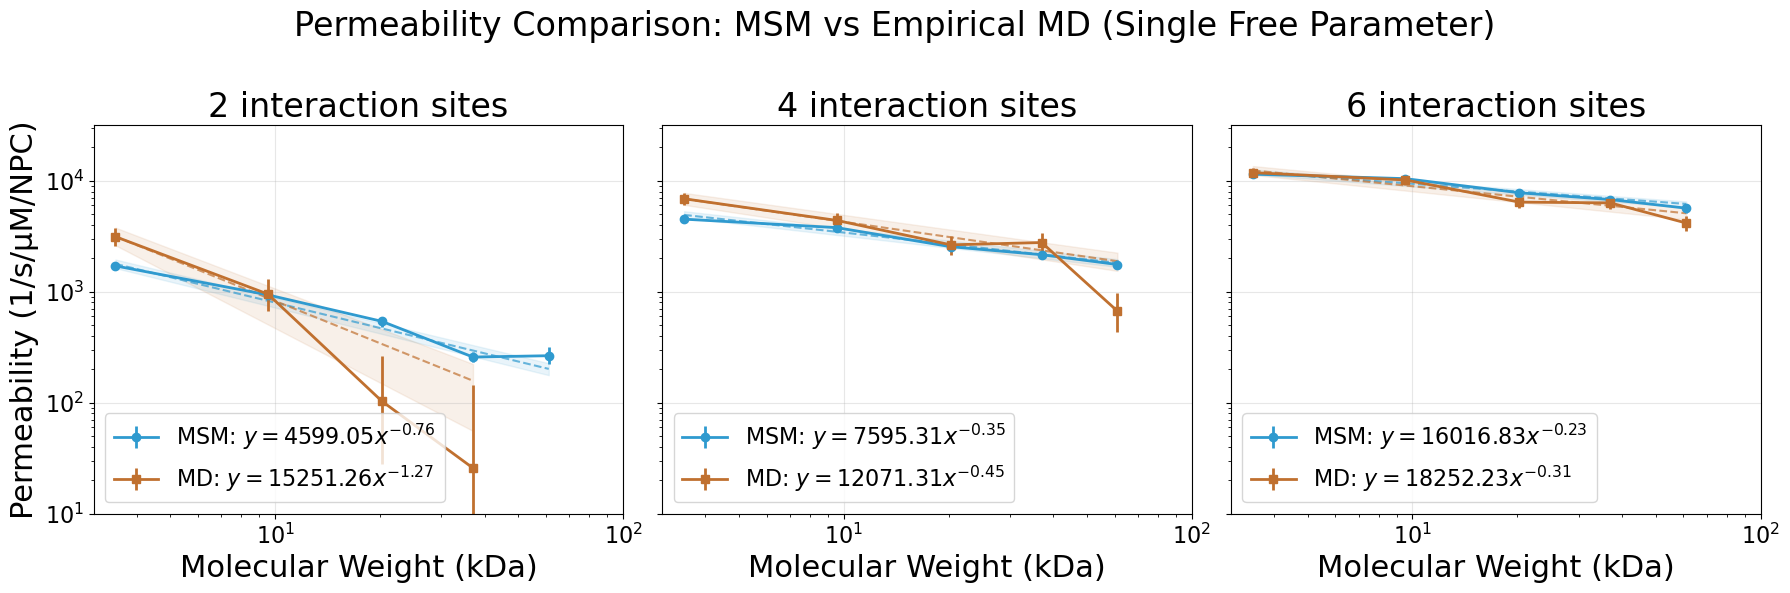


Summary Statistics:
 sites  radius       kda  total_transports  n_trajs  permeability  lower_permeability  upper_permeability
     2      10  3.478309               122     3000    626.945001          520.639931          748.573204
     2      14  9.544481                37     3000    190.139058          133.875444          262.081645
     2      18 20.285500                 4     3000     20.555574            5.600702           52.630433
     2      22 37.037037                 1     3000      5.138893            0.130106           28.632082
     2      26 61.134764                 0     3000      0.000000            0.000000           18.956758
     4      10  3.478309               268     3000   1377.223444         1217.256894         1552.368352
     4      14  9.544481               171     3000    878.750780          751.974452         1020.781296
     4      18 20.285500               103     3000    529.306025          432.036733          641.937493
     4      22 37.037037 

In [ ]:
# print(df_results_emp.to_string(index=False))




def plot_permeability_dataset(ax, data, x_col, y_col, low_col, high_col, color, label, marker):
    if data.empty:
        return

    data = data.sort_values(x_col)
    y_err_lower = data[y_col] - data[low_col]
    y_err_upper = data[high_col] - data[y_col]
    y_err = (y_err_lower + y_err_upper) / 2

    x_fit, y_fit, slope, intercept = weighted_power_law_fit(data[x_col], data[y_col], y_err)
    x_fit_lo, y_fit_lo, _, _ = weighted_power_law_fit(data[x_col], data[low_col], y_err)
    x_fit_hi, y_fit_hi, _, _ = weighted_power_law_fit(data[x_col], data[high_col], y_err)

    ax.plot(x_fit, y_fit, linestyle='--', color=color, alpha=0.7)
    ax.fill_between(x_fit, y_fit_lo, y_fit_hi, color=color, alpha=0.1)
    ax.errorbar(
        data[x_col],
        data[y_col],
        yerr=[y_err_lower, y_err_upper],
        marker=marker,
        label=fr'{label}: $y={10**intercept:.2f}x^{{{slope:.2f}}}$',
        color=color,
        linewidth=2,
    )

colors = {"MSM": "#2f9acf", "Empirical": "#c0702f"}
site_values = [2, 4, 6]

fig, axes = plt.subplots(1, len(site_values), figsize=(18, 6), sharey=True)
fig.suptitle('Permeability Comparison: MSM vs Empirical MD (Single Free Parameter)', fontsize=24)

for ax, site in zip(axes, site_values):
    msm_site = df_results_tm[df_results_tm['sites'] == site]
    emp_site = df_results_emp[df_results_emp['sites'] == site]
    if site == 2 and 'total_transports' in emp_site:
        emp_site = emp_site[emp_site['total_transports'] > 0]
    free_coeff = 5 # single free parameter
    # emp_site['permeability'] = emp_site['permeability'] * free_coeff 
    # emp_site['lower_permeability'] = emp_site['lower_permeability'] * free_coeff
    # emp_site['upper_permeability'] = emp_site['upper_permeability'] * free_coeff
    # # actually use loc
    emp_site.loc[:, 'permeability'] = emp_site['permeability'] * free_coeff
    emp_site.loc[:, 'lower_permeability'] = emp_site['lower_permeability'] * free_coeff
    emp_site.loc[:, 'upper_permeability'] = emp_site['upper_permeability'] * free_coeff

    ax.set_title(f'{site} interaction sites', fontsize=24)
    plot_permeability_dataset(
        ax,
        msm_site,
        'kda',
        'median_permeability',
        'lower_permeability',
        'upper_permeability',
        colors['MSM'],
        'MSM',
        'o',
    )
    plot_permeability_dataset(
        ax,
        emp_site,
        'kda',
        'permeability',
        'lower_permeability',
        'upper_permeability',
        colors['Empirical'],
        'MD',
        's',
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([10**1, 10**2])
    ax.set_xticklabels([r'$10^1$', r'$10^2$'])
    ax.set_ylim(10, 10**4.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Molecular Weight (kDa)', fontsize=22)
    ax.legend(fontsize=16, loc='lower left')
    
    # set tick font size
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

axes[0].set_ylabel('Permeability (1/s/µM/NPC)', fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df_results_emp.to_string(index=False))

In [40]:
radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]
sites_list = [2, 4, 6]
n_clusters = 80

sites_to_fitted_perms = {}
sites_to_fitted_perms_lo = {}
sites_to_fitted_perms_hi = {}

for sites in sites_list:
    sites_perms = []
    sites_perms_lower = []
    sites_perms_upper = []
    sites_errs = []
    for radius in radii:
        clustered_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustered_subsets/1.00fraction/{0}index/{n_clusters}clusters.pickle"
        clustering_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustering_subsets/1.00fraction/{0}index/{n_clusters}clusters.pickle"
        results = collect_perms_md_single_type(time_us=60, n_trajs=3000, clustered_path=clustered_path, clustering_path=clustering_path)
        perms = results[2]
        perms_lower = results[3]
        perms_upper = results[4]
        y_err_lower = perms - perms_lower
        y_err_upper = perms_upper - perms
        y_err = (y_err_lower + y_err_upper) / 2
        sites_perms.append(perms)
        sites_perms_lower.append(perms_lower)
        sites_perms_upper.append(perms_upper)
        sites_errs.append(y_err)
    sites_perms = np.array(sites_perms)
    sites_perms_lower = np.array(sites_perms_lower)
    sites_perms_upper = np.array(sites_perms_upper)
    sites_errs = np.array(sites_errs)
    _, _, slope, intercept, y_fit = weighted_power_law_fit(kdas, sites_perms, sites_errs)
    _, _, _, _, y_fit_lo = weighted_power_law_fit(kdas, sites_perms_lower, sites_errs)
    _, _, _, _, y_fit_hi = weighted_power_law_fit(kdas, sites_perms_upper, sites_errs)
    sites_to_fitted_perms[sites] = y_fit
    sites_to_fitted_perms_lo[sites] = y_fit_lo
    sites_to_fitted_perms_hi[sites] = y_fit_hi
    

subsets = [0.04, 0.05, 0.1, 0.25, 0.5, 0.75, 1]
total_simulation_times = [60 * 30 * subset for subset in subsets]

# Create a grid: rows = radii, cols = sites

perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
lower_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
upper_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
perms_all_msm = np.zeros((len(radii), len(sites_list), len(subsets)))


for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):

        # Collect MSM permeabilities
        perm_by_subset_size = []
        for k, subset in enumerate(subsets):
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction/{0}index/7_permeabilities.pickle", "rb") as f:
                perms = pickle.load(f)
                perms_all_msm[i, j, k] = perms[n_clusters]
        
        # Collect MD permeabilities
        md_perms = []
        md_lower_perms = []
        md_upper_perms = []
        for k, subset in enumerate(subsets):
            clustered_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustered_subsets/{subset:.2f}fraction/{0}index/{n_clusters}clusters.pickle"
            clustering_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustering_subsets/{subset:.2f}fraction/{0}index/{n_clusters}clusters.pickle"
            if radius == 26 and sites == 2:
                pass
            results = collect_perms_md_single_type(subset * 60, 3000, clustered_path, clustering_path)
            perms_all_md[i, j, k] = results[2]
            lower_perms_all_md[i, j, k] = results[3]
            upper_perms_all_md[i, j, k] = results[4]

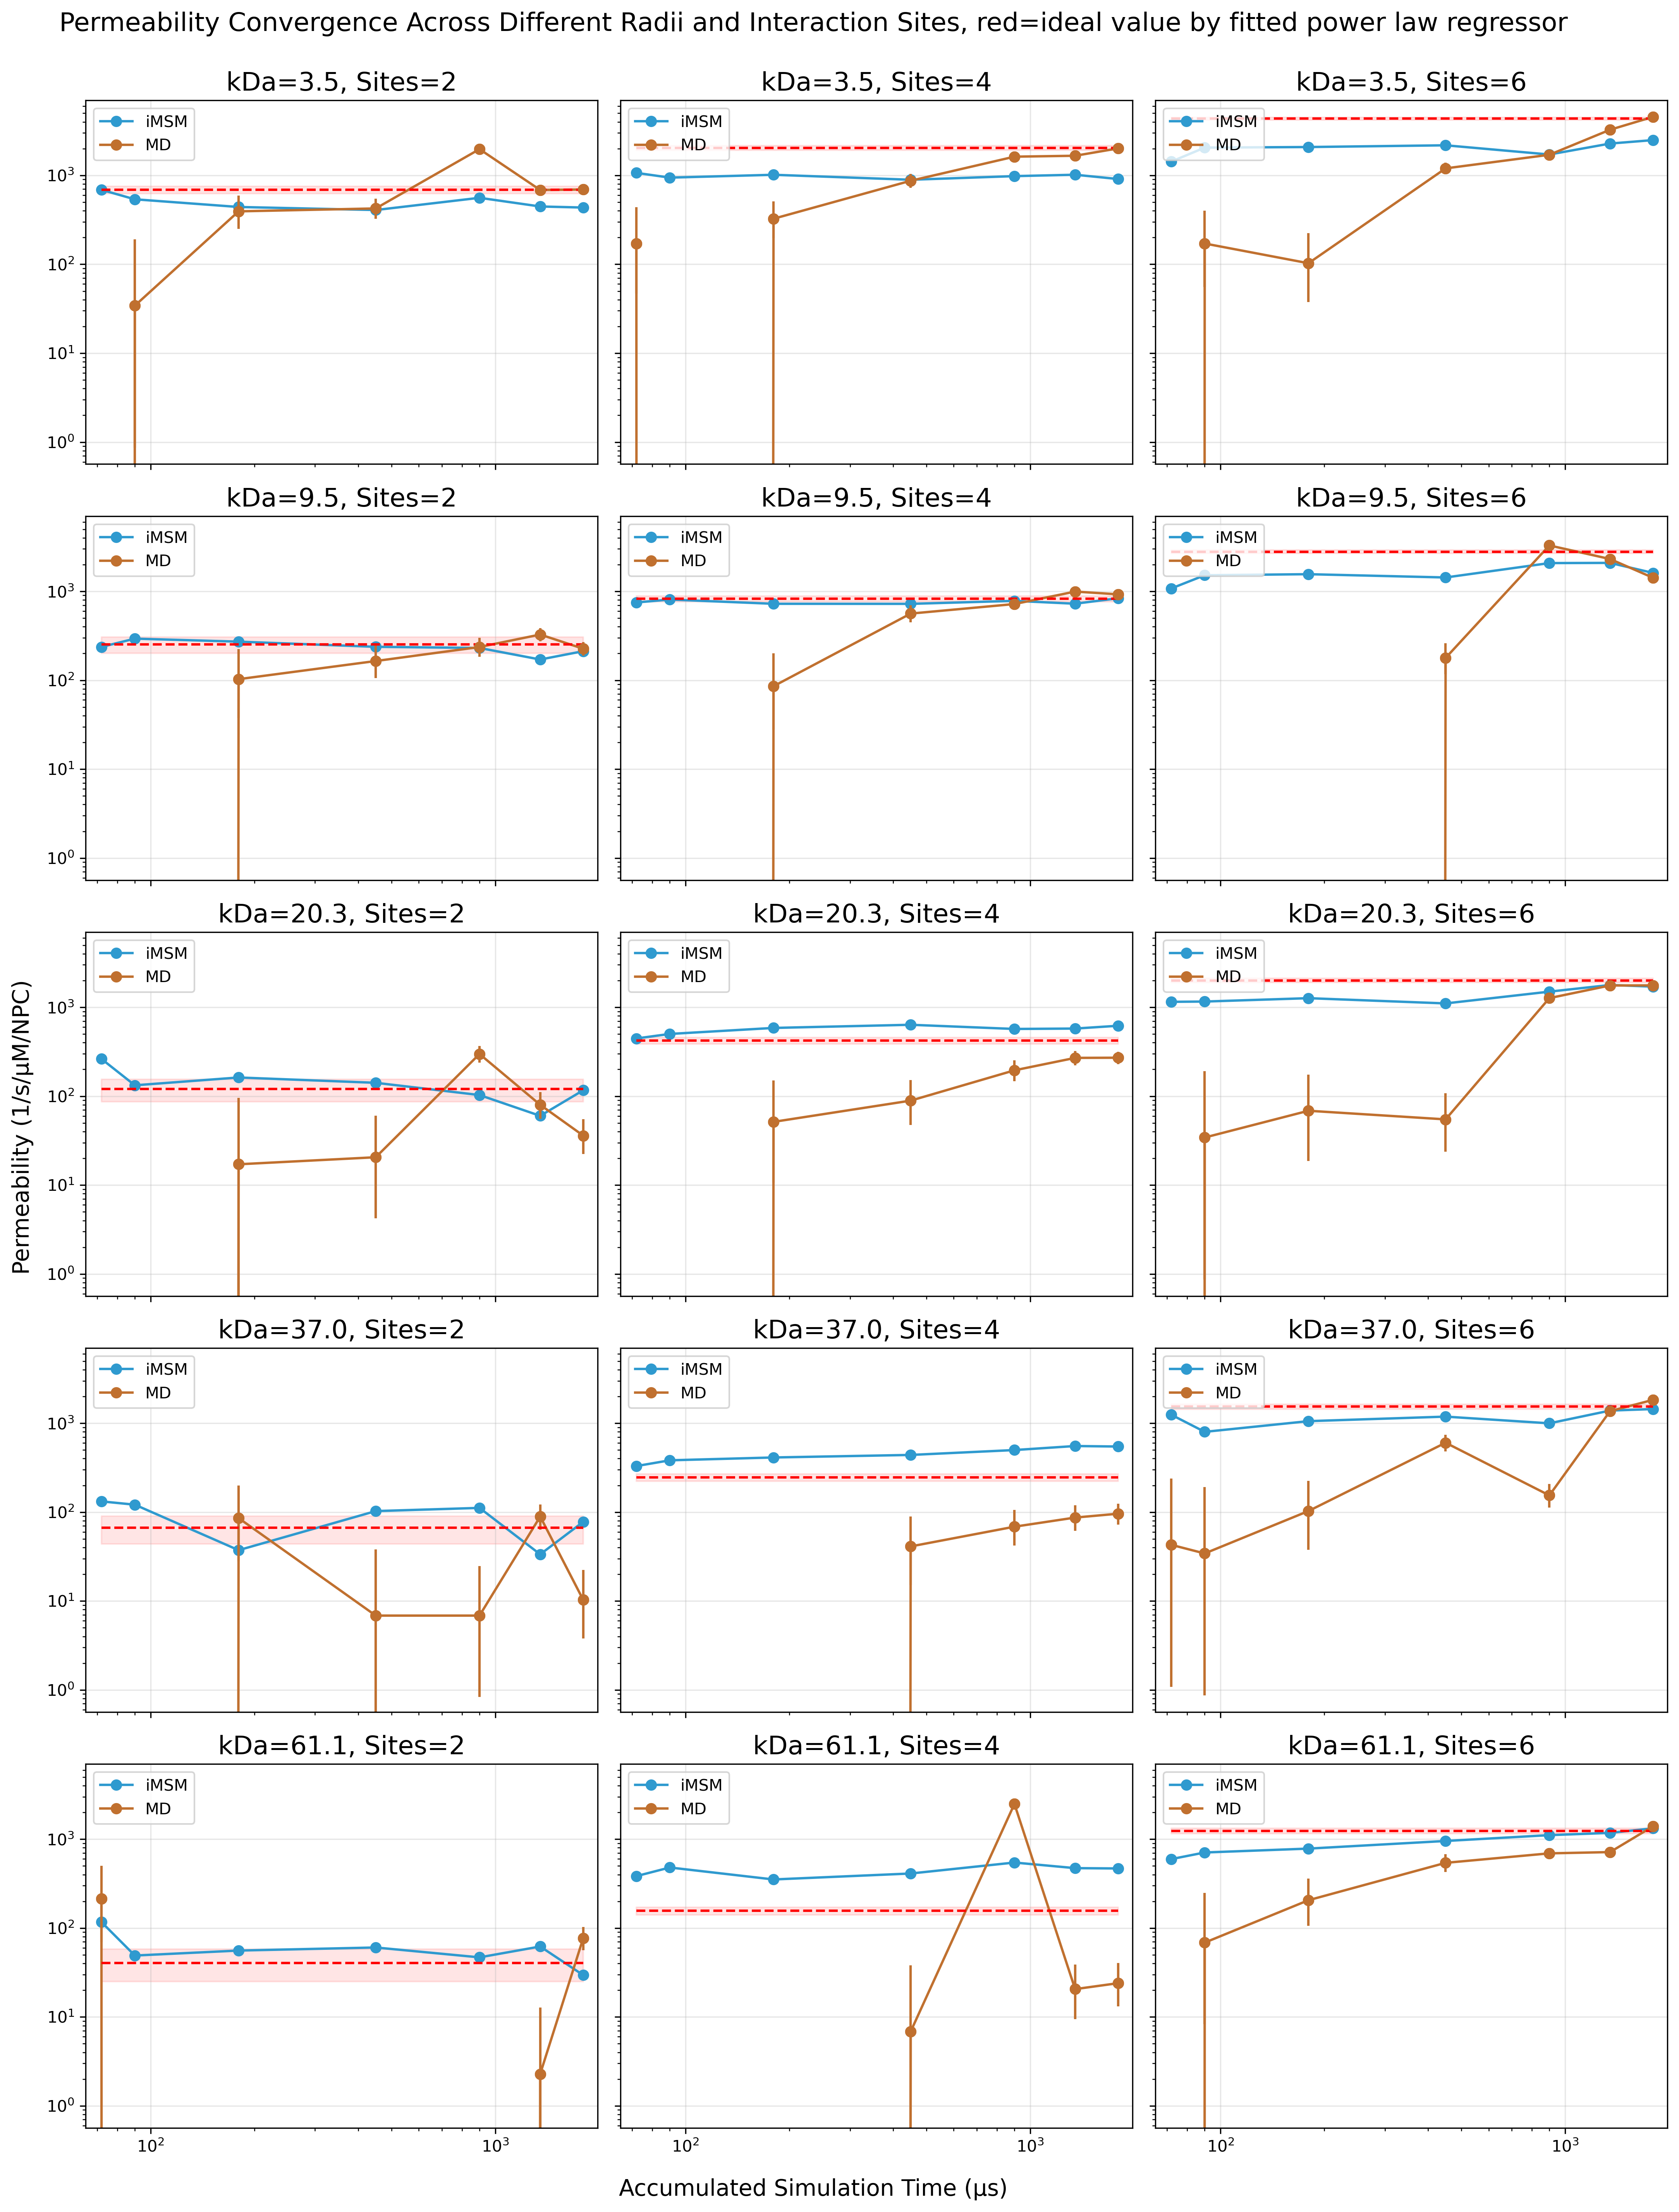

In [47]:
fig, axes = plt.subplots(len(radii), len(sites_list), figsize=(15, 20), sharex=True, sharey=True, dpi=300)

for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        ax = axes[i, j]
        md_perms = perms_all_md[i, j, :]
        md_lower_perms = lower_perms_all_md[i, j, :]
        md_upper_perms = upper_perms_all_md[i, j, :]
        msm_perms = perms_all_msm[i, j, :]
        
        # Plot
        ax.plot(total_simulation_times, msm_perms / 5, marker='o', label='iMSM', color="#2f9acf")
        ax.plot(total_simulation_times, md_perms, marker='o', label='MD', color="#c0702f")
        ax.errorbar(
            total_simulation_times,
            md_perms,
            yerr=[np.array(md_perms) - np.array(md_lower_perms), np.array(md_upper_perms) - np.array(md_perms)],
            fmt='o',
            color="#c0702f"
        )
        
        # Add title for each subplot
        ax.set_title(f'kDa={kdas[i]:.1f}, Sites={sites}', fontsize=16)
        
        ax.legend(loc='upper left')
        
        # Grid
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # add red dashed line for the final md value
        ax.plot(total_simulation_times, [sites_to_fitted_perms[sites][i]] * len(total_simulation_times), color='red', linestyle='--')
        ax.fill_between(total_simulation_times, sites_to_fitted_perms_lo[sites][i], sites_to_fitted_perms_hi[sites][i], color='red', alpha=0.1)
        
        ax.set_xlim(total_simulation_times[0]*0.9, total_simulation_times[-1]*1.1)

# Add common axis labels
fig.text(0.5, 0.04, 'Accumulated Simulation Time (μs)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Permeability (1/s/µM/NPC)', va='center', rotation='vertical', fontsize=14)

fig.suptitle('Permeability Convergence Across Different Radii and Interaction Sites, red=ideal value by fitted power law regressor', fontsize=16)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
plt.show()

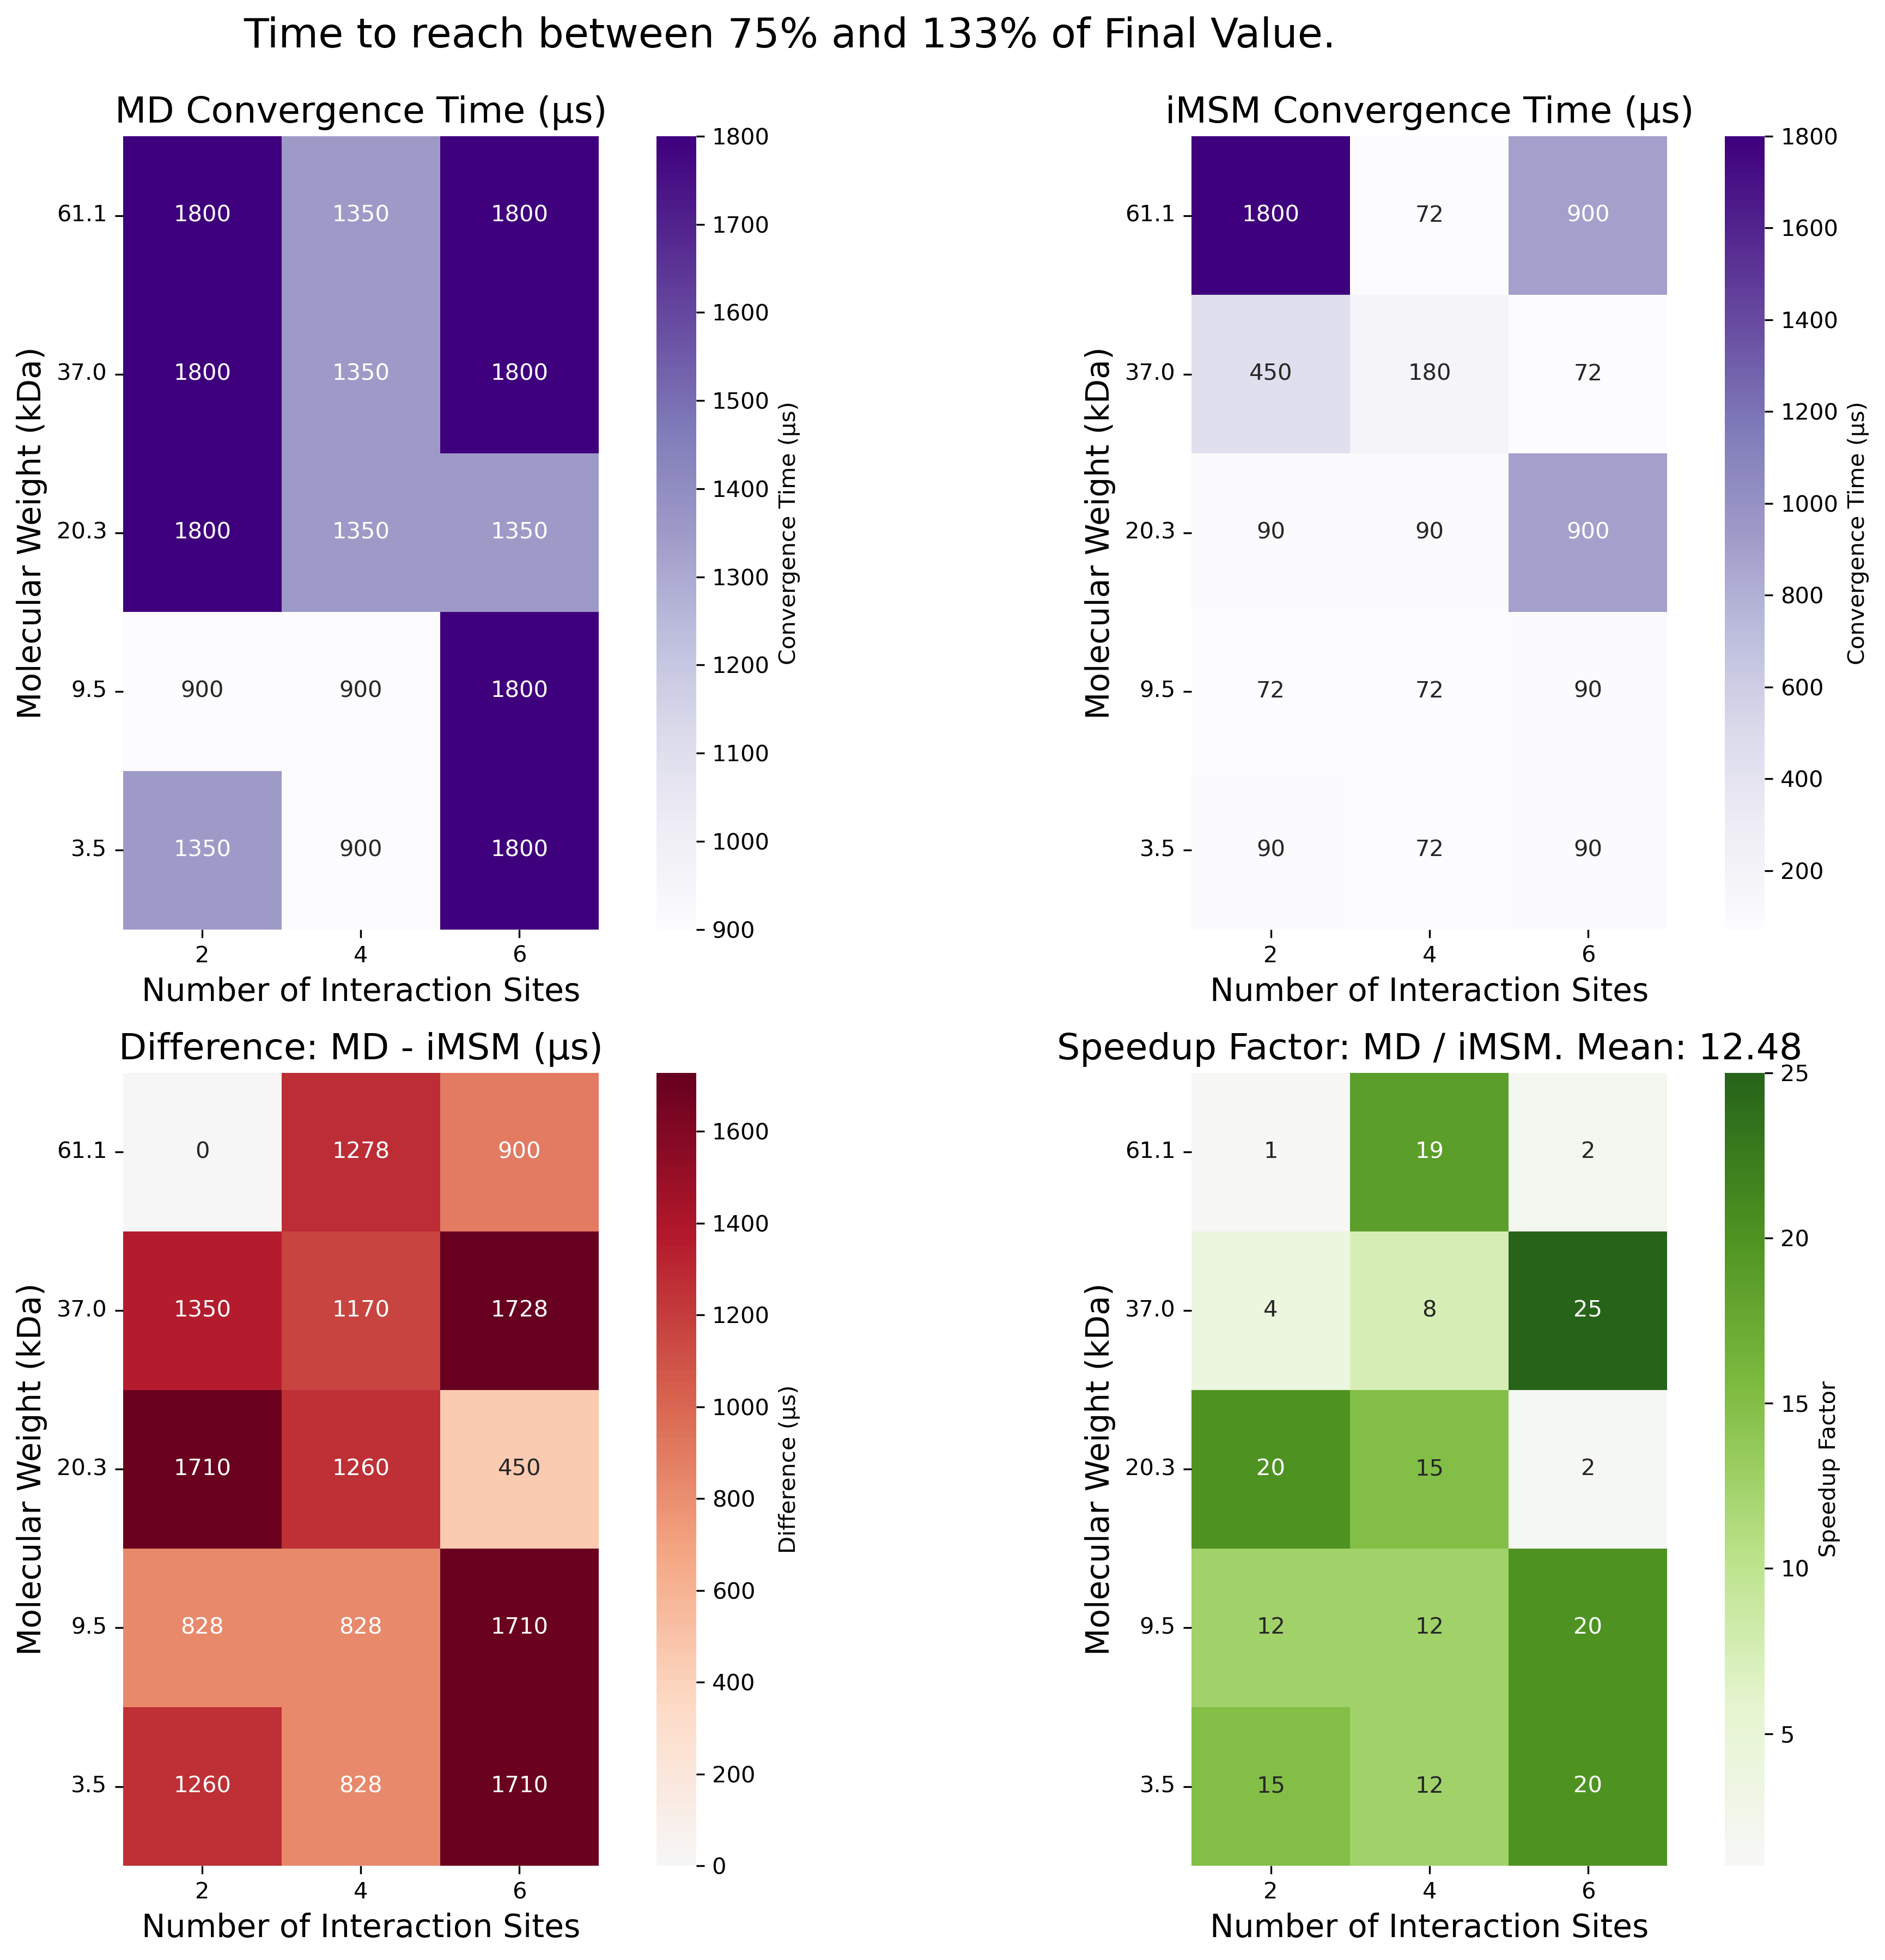

In [49]:
min_convergence_factor = 0.75
max_convergence_factor = 1.33

# min_convergence_factor = 0.5
# max_convergence_factor = 1.5


md_convergences = np.zeros((len(radii), len(sites_list)))
msm_convergences = np.zeros((len(radii), len(sites_list)))
for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        md_perms = perms_all_md[i, j, :]
        msm_perms = perms_all_msm[i, j, :]
        final_md_perm = md_perms[-1]
        final_msm_perm = msm_perms[-1]
        for k in range(len(subsets)):
            if md_perms[k] >= min_convergence_factor * final_md_perm and md_perms[k] <= max_convergence_factor * final_md_perm:
                md_convergences[i, j] = total_simulation_times[k]
                break
        for k in range(len(subsets)):
            if msm_perms[k] >= min_convergence_factor * final_msm_perm and msm_perms[k] <= max_convergence_factor * final_msm_perm:
                msm_convergences[i, j] = total_simulation_times[k]
                break

# visualize as heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
fig.suptitle('Time to reach between 75% and 133% of Final Value. ', 
             fontsize=18, y=0.995)

# MD heatmap
sns.heatmap(md_convergences[::-1], annot=True, fmt='.0f', cmap='Purples', 
            ax=axes[0, 0], cbar_kws={'label': 'Convergence Time (μs)'}, square=True)
axes[0, 0].set_xticklabels(sites_list)
axes[0, 0].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[0, 0].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[0, 0].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[0, 0].set_title('MD Convergence Time (μs)', fontsize=16)

# MSM heatmap
sns.heatmap(msm_convergences[::-1], annot=True, fmt='.0f', cmap='Purples', 
            ax=axes[0, 1], cbar_kws={'label': 'Convergence Time (μs)'}, square=True)
axes[0, 1].set_xticklabels(sites_list)
axes[0, 1].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[0, 1].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[0, 1].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[0, 1].set_title('iMSM Convergence Time (μs)', fontsize=16)

# Difference heatmap (MD - MSM)
diff_convergences = md_convergences - msm_convergences
sns.heatmap(diff_convergences[::-1], annot=True, fmt='.0f', cmap='RdBu_r', center=0,
            ax=axes[1, 0], cbar_kws={'label': 'Difference (μs)'}, square=True)
axes[1, 0].set_xticklabels(sites_list)
axes[1, 0].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[1, 0].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[1, 0].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[1, 0].set_title('Difference: MD - iMSM (μs)', fontsize=16)

# Speedup factor heatmap (MD / MSM)
speedup_factor = md_convergences / msm_convergences
sns.heatmap(speedup_factor[::-1], annot=True, fmt='.0f', cmap='PiYG', center=1,
            ax=axes[1, 1], cbar_kws={'label': 'Speedup Factor'}, square=True)
axes[1, 1].set_xticklabels(sites_list)
axes[1, 1].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[1, 1].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[1, 1].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[1, 1].set_title(f'Speedup Factor: MD / iMSM. Mean: {np.mean(speedup_factor):.2f}', fontsize=16)

plt.tight_layout()